In [78]:
import pandas as pd
import numpy as np
import seaborn as sns


In [79]:
df=pd.read_csv("medical_charges.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [80]:
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [81]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [82]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
    

In [83]:
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [84]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [85]:
X = df.drop(["charges"],axis=1)
y = df["charges"]

In [86]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,1
1,18,1,33.770,1,0,0,1,0
2,28,1,33.000,3,0,0,1,0
3,33,1,22.705,0,0,1,0,0
4,32,1,28.880,0,0,1,0,0


In [87]:
from sklearn.model_selection import train_test_split
X_train,X_valid,y_train,y_valid=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [88]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [89]:
y_pred=lr.predict(X_valid)
y_pred

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084136, 16903.45028662,
        1092.43093614, 11218.34318352, 28101.68455267,  9377.73460205,
        5263.0595179 , 38416.04221107, 40255.82339284, 37098.25353123,
       15240.39392306, 35912.88264434,  9112.52398703, 31461.92108909,
        3847.68845883, 10130.12001517,  2370.54189389,  7140.21550828,
       11301.76782638, 12961.65366224, 14509.47251876,  6159.8976107 ,
        9963.85857263,  2177.85718217,  9115.93673494, 13073.68932159,
        4561.82376202,  3408.20756033,  4459.81359745, 13032.06505076,
        1979.99357292,  8813.28303302, 33271.29124448, 32585.51583927,
        3908.76090964,  4326.10774721, 14142.81326533, 11423.45494846,
        8774.13955311, 12097.28051001,  5281.57353499,  3150.5596042 ,
       35494.46461214,  9150.1124786 , 15836.84575621,  2343.57470069,
       12364.78414194,  1482.29488266, 13389.06105161, 12573.57395972,
      

In [90]:
y_valid

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))

MAE : 4181.194473753647
MSE : 33596915.851361446
RMSE: 5796.284659276272
R2  : 0.7835929767120724


In [92]:

from sklearn.linear_model import RidgeCV
a=[0.01,0.1,2,5,20,30,50,100]
rcv=RidgeCV(
    alphas=a,
    cv=5
)
rcv.fit(X_train,y_train)
y_pred=rcv.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))
print("best alpha",rcv.alpha_)

MAE : 4182.428134240745
MSE : 33601489.864824004
RMSE: 5796.679210101591
R2  : 0.7835635142268166
best alpha 0.1


In [94]:
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor(max_depth=5)
dtr.fit(X_train,y_train)
y_pred=dtr.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))


MAE : 2930.7675712410437
MSE : 25831862.599857908
RMSE: 5082.505543514725
R2  : 0.8336098314514943


In [101]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor(n_estimators=200,max_depth=4,max_leaf_nodes=25)
rfr.fit(X_train,y_train)
y_pred=rfr.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))

MAE : 2595.446951318682
MSE : 19890618.866158564
RMSE: 4459.8900060605265
R2  : 0.871879024871694


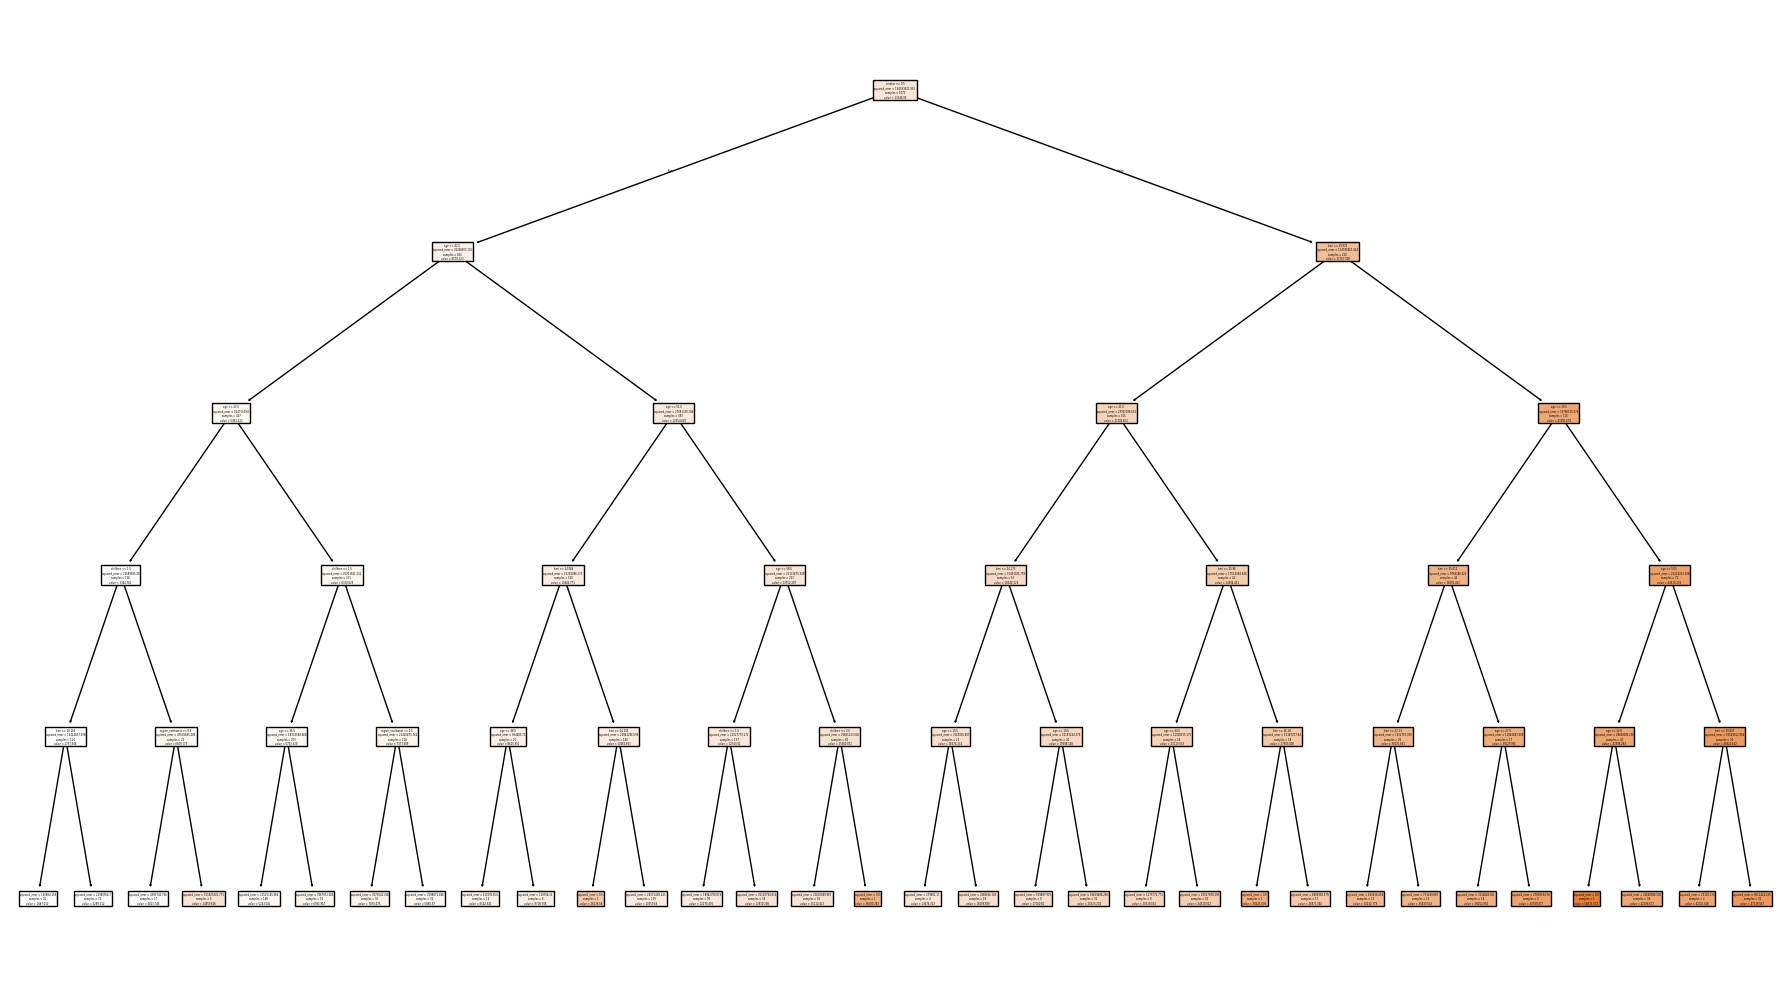

In [102]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    dtr,
    feature_names =X.columns,
    filled=True
)
plt.tight_layout()


In [103]:
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor(learning_rate=0.1, n_estimators=100, subsample=0.8)

gbr.fit(X_train,y_train)
y_pred=gbr.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))

MAE : 2450.3668417021054
MSE : 18873442.536724526
RMSE: 4344.35755166682
R2  : 0.878430938820749


In [98]:
import xgboost as xgb
model1 = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)
model1.fit(X_train,y_train)
y_pred=model1.predict(X_valid)
print("MAE :", mean_absolute_error(y_valid, y_pred))
print("MSE :", mean_squared_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2  :", r2_score(y_valid, y_pred))

MAE : 2432.049324739739
MSE : 18030522.49132493
RMSE: 4246.236273610423
R2  : 0.883860419869


## 🏆 Best Model

After comparing all the regression models, **XGBoost Regressor** achieved the best performance.

- **Best Model:** XGBoost Regressor
- **R² Score:** **88.38%**

An R² score of **88.38%** indicates that the XGBoost model explains approximately **88.38% of the variation in annual medical costs**, making it the best-performing model among the algorithms evaluated.